In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
!mv Merged\ News\ Dataset\ 14-12-2024.xlsx "/content/drive/MyDrive/your_file.xlsx"

mv: cannot stat 'Merged News Dataset 14-12-2024.xlsx': No such file or directory


In [6]:
import torch

# Activate GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# Example tensor computations on GPU
# Any tensor you create must be moved to the device

# Create tensors directly on GPU:
a = torch.randn(3, 3, device=device)
b = torch.randn(3, 3, device=device)
c = a + b  # This computation happens on GPU

print("Tensor a (on GPU):", a)
print("Tensor b (on GPU):", b)
print("Result c (on GPU):", c)

# Example: Matrix multiplication on GPU
d = torch.matmul(a, b)
print("Matrix multiplication result d (on GPU):", d)

# To move existing CPU tensors to GPU:
x_cpu = torch.randn(5, 5)
x_gpu = x_cpu.to(device)
print("x_gpu is on device:", x_gpu.device)

# To confirm:
print("✅ GPU computations complete.")

✅ Using device: cuda
Tensor a (on GPU): tensor([[-0.5215, -1.0747, -0.9943],
        [ 0.0093, -0.3774, -0.5046],
        [ 0.4586,  1.2539, -0.2763]], device='cuda:0')
Tensor b (on GPU): tensor([[ 0.3587,  1.0270,  0.4668],
        [ 0.6289,  1.8792, -0.9001],
        [-0.4829,  0.9849,  0.5564]], device='cuda:0')
Result c (on GPU): tensor([[-0.1628, -0.0476, -0.5275],
        [ 0.6381,  1.5019, -1.4047],
        [-0.0243,  2.2388,  0.2802]], device='cuda:0')
Matrix multiplication result d (on GPU): tensor([[-0.3827, -3.5344,  0.1706],
        [ 0.0097, -1.1967,  0.0632],
        [ 1.0864,  2.5553, -1.0682]], device='cuda:0')
x_gpu is on device: cuda:0
✅ GPU computations complete.


In [7]:
import pandas as pd
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Load your Excel file
file_path = "/content/drive/MyDrive/your_file.xlsx"  # or newsumm_dataset.xlsx if you renamed
df = pd.read_excel(file_path, sheet_name=0)

# Check data
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,newspaper_name,published_date\n,headline,article_text,human_summary,news_category
0,Indian Express,2020-06-01 00:00:00,Virus may be invisible enemy but COVID warrior...,Prime Minister Narendra Modi Monday hailed the...,Prime Minister of India said that the Virus ma...,National News
1,Economic Times,2013-02-11 00:00:00,"Economy can bounce back, says PM Modi","ALLAHABAD: At least 20 persons were killed, an...","In Maha Kumbh, nearly 20 persons were killed. ...",National News
2,Business Standard,2013-02-11 00:00:00,At least 20 killed in stampede in Allahabad,"At least 20 people were killed, and scores of ...",As per the sources 20 people died and scores w...,National News
3,Money Control,2013-02-11 00:00:00,Maha Kumbh: Over 20 dead in Allahabad station ...,More than 20 people were feared dead and 30 ot...,At least 20 people killed and 20 people are in...,National News
4,The Mint,2023-10-02 00:00:00,Gandhian wisdom,"This Gandhi Jayanti, we should reflect upon an...","In this article, the author reflects on Mahatm...",National News


In [8]:
df.columns = [col.strip() for col in df.columns]

In [9]:
print(df.columns)
print(df.dtypes)

Index(['newspaper_name', 'published_date', 'headline', 'article_text',
       'human_summary', 'news_category'],
      dtype='object')
newspaper_name    object
published_date    object
headline          object
article_text      object
human_summary     object
news_category     object
dtype: object


In [10]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')

In [11]:
print(df.dtypes)

newspaper_name            object
published_date    datetime64[ns]
headline                  object
article_text              object
human_summary             object
news_category             object
dtype: object


In [12]:
# Oldest and newest article dates
print("Earliest date:", df['published_date'].min())
print("Latest date:", df['published_date'].max())

# Count of articles per year
df['year'] = df['published_date'].dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)


Earliest date: 1838-02-12 00:00:00
Latest date: 2104-04-09 00:00:00
year
1838.0    3
1878.0    3
1900.0    1
1919.0    1
1924.0    1
         ..
2029.0    2
2030.0    2
2033.0    1
2035.0    1
2104.0    1
Name: count, Length: 88, dtype: int64


In [13]:
missing_values = df.isnull().sum()
print(missing_values)

newspaper_name      4
published_date    721
headline            5
article_text       27
human_summary     239
news_category       6
year              721
dtype: int64


In [14]:
df['article_length'] = df['article_text'].astype(str).apply(len)
df['summary_length'] = df['human_summary'].astype(str).apply(len)

In [15]:
print(df[['article_length', 'summary_length']].describe())

       article_length  summary_length
count   317305.000000   317305.000000
mean      2093.633340      631.940669
std       1720.369056      378.759048
min          1.000000        1.000000
25%        952.000000      399.000000
50%       1723.000000      609.000000
75%       2693.000000      745.000000
max      32213.000000    27948.000000


In [16]:
total_articles = len(df)
print(f"Total articles: {total_articles}")

Total articles: 317305


In [17]:
# Count total words in all articles
total_words = df['article_text'].astype(str).apply(lambda x: len(x.split())).sum()
print(f"Total words in article_text: {total_words}")


Total words in article_text: 108423420


In [18]:
!pip install nltk

In [19]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
from nltk.tokenize import sent_tokenize

test_text = "Hello. This is a test sentence. Checking if punkt works."
print(sent_tokenize(test_text))

['Hello.', 'This is a test sentence.', 'Checking if punkt works.']


In [21]:
total_sentences_articles = df['article_text'].astype(str).apply(lambda x: len(sent_tokenize(x))).sum()
print(f"✅ Total sentences in article_text: {total_sentences_articles}")

# Total sentences in human_summary
total_sentences_summaries = df['human_summary'].astype(str).apply(lambda x: len(sent_tokenize(x))).sum()
print(f"✅ Total sentences in human_summary: {total_sentences_summaries}")

✅ Total sentences in article_text: 4652998
✅ Total sentences in human_summary: 1481410


In [22]:
avg_words_per_article = total_words / total_articles
print(f"✅ Average words per article: {avg_words_per_article:.2f}")

✅ Average words per article: 341.70


In [23]:
total_words_summaries = df['human_summary'].astype(str).apply(lambda x: len(x.split())).sum()
avg_words_per_summary = total_words_summaries / total_articles
print(f"✅ Average words per summary: {avg_words_per_summary:.2f}")

✅ Average words per summary: 95.45


In [24]:
avg_sentences_per_article = total_sentences_articles / total_articles
print(f"✅ Average sentences per article: {avg_sentences_per_article:.2f}")

✅ Average sentences per article: 14.66


In [25]:
avg_sentences_per_summary = total_sentences_summaries / total_articles
print(f"✅ Average sentences per summary: {avg_sentences_per_summary:.2f}")

✅ Average sentences per summary: 4.67


In [26]:
# Check unique categories
print("Unique categories found:", df['news_category'].unique())

# Compute value counts for each category
category_counts = df['news_category'].value_counts()

# Display category counts
print("\nCategory distribution in NewsSumm:")
print(category_counts)

# Optional: convert to percentage
category_percent = (category_counts / category_counts.sum()) * 100
print("\nCategory distribution in percentage:")
print(category_percent.round(2))

Unique categories found: ['National News' 'Business and Finance' 'Politics' ...
 'International Security/Terrorism' ' COVID-19 Impact' 'Avaiation']

Category distribution in NewsSumm:
news_category
Politics                     44189
Business and Finance         30089
National News                29944
Local News                   28349
International News           23567
                             ...  
RELIGION                         1
LABOUR                           1
Industrial tragedy               1
COMMUNAL VIOLENCE                1
Government administration        1
Name: count, Length: 5121, dtype: int64

Category distribution in percentage:
news_category
Politics                     13.93
Business and Finance          9.48
National News                 9.44
Local News                    8.93
International News            7.43
                             ...  
RELIGION                      0.00
LABOUR                        0.00
Industrial tragedy            0.00
COMMUNAL V

In [27]:
print(df.columns.tolist())

['newspaper_name', 'published_date', 'headline', 'article_text', 'human_summary', 'news_category', 'year', 'article_length', 'summary_length']


✅ Total tokens in articles: 123674109
✅ Total tokens in summaries: 34845065
✅ Average tokens per article: 389.76
✅ Average tokens per summary: 109.82


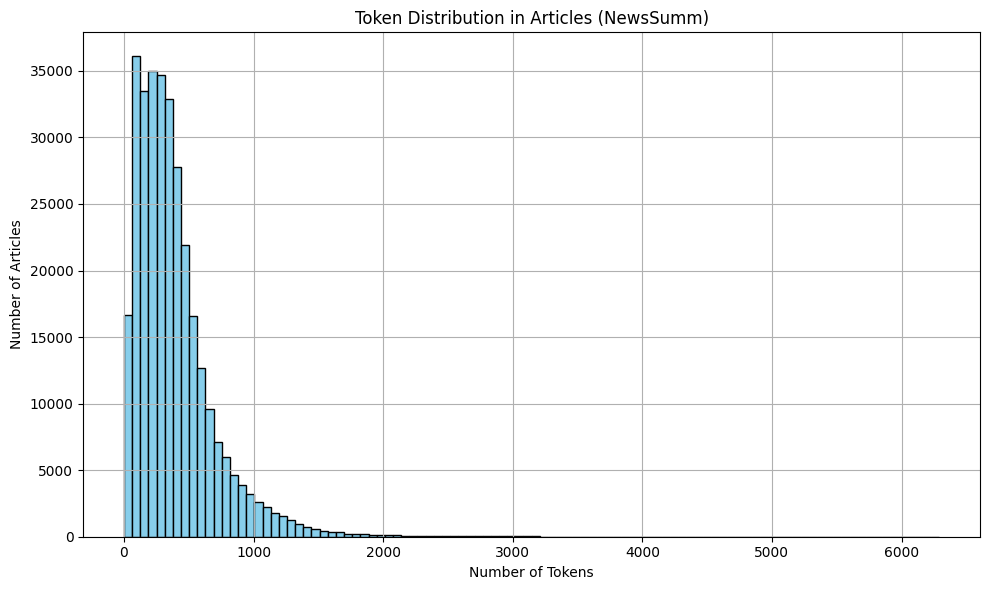

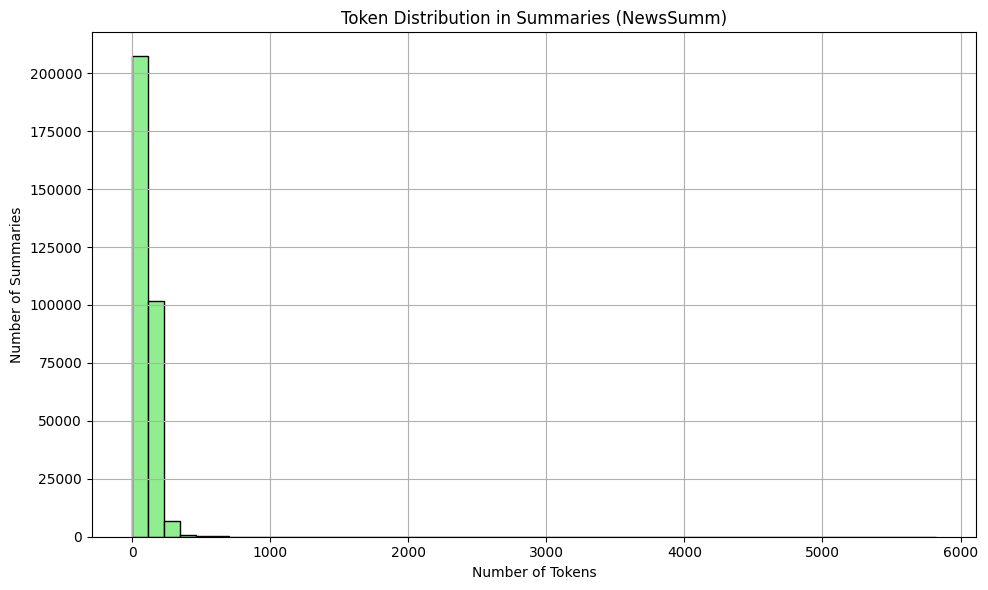

In [28]:
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import pandas as pd

# Clean columns
df.columns = [col.strip().lower().replace(" ", "_").replace("\n", "") for col in df.columns]

# Token count helper
def count_tokens(text):
    return len(word_tokenize(str(text)))

# 1️⃣ Total tokens
df['article_tokens'] = df['article_text'].apply(count_tokens)
df['summary_tokens'] = df['human_summary'].apply(count_tokens)

total_tokens_articles = df['article_tokens'].sum()
total_tokens_summaries = df['summary_tokens'].sum()

print(f"✅ Total tokens in articles: {total_tokens_articles}")
print(f"✅ Total tokens in summaries: {total_tokens_summaries}")

# 2️⃣ Average tokens per article/summary
avg_tokens_article = df['article_tokens'].mean()
avg_tokens_summary = df['summary_tokens'].mean()

print(f"✅ Average tokens per article: {avg_tokens_article:.2f}")
print(f"✅ Average tokens per summary: {avg_tokens_summary:.2f}")

# 3️⃣ Token distribution histogram for articles
plt.figure(figsize=(10,6))
plt.hist(df['article_tokens'], bins=100, color='skyblue', edgecolor='black')
plt.title('Token Distribution in Articles (NewsSumm)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.tight_layout()
plt.show()

# Token distribution histogram for summaries
plt.figure(figsize=(10,6))
plt.hist(df['summary_tokens'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Token Distribution in Summaries (NewsSumm)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Summaries')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.util import ngrams
import pandas as pd

# Concatenate all article texts for analysis
all_text = " ".join(df['article_text'].astype(str).tolist())

# Tokenize
tokens = word_tokenize(all_text.lower())

# 1️⃣ Vocabulary size
vocab = set(tokens)
vocab_size = len(vocab)
print(f"✅ Vocabulary size: {vocab_size}")

# 2️⃣ Unigram frequencies
unigrams = FreqDist(tokens)
top_unigrams = unigrams.most_common(50)
print("\n✅ Top 50 Unigrams:")
for word, freq in top_unigrams:
    print(f"{word}: {freq}")

# 3️⃣ Bigram frequencies
bigrams = FreqDist(ngrams(tokens, 2))
top_bigrams = bigrams.most_common(50)
print("\n✅ Top 50 Bigrams:")
for phrase, freq in top_bigrams:
    print(f"{' '.join(phrase)}: {freq}")

# 4️⃣ Trigram frequencies
trigrams = FreqDist(ngrams(tokens, 3))
top_trigrams = trigrams.most_common(50)
print("\n✅ Top 50 Trigrams:")
for phrase, freq in top_trigrams:
    print(f"{' '.join(phrase)}: {freq}")

# 5️⃣ Optional: Plot top unigrams
unigram_words, unigram_freqs = zip(*top_unigrams)
plt.figure(figsize=(12,6))
plt.bar(unigram_words, unigram_freqs, color='skyblue')
plt.title('Top 50 Unigrams in NewsSumm')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 6️⃣ Optional: Plot top bigrams
bigram_phrases = [' '.join(b) for b, _ in top_bigrams]
bigram_freqs = [f for _, f in top_bigrams]
plt.figure(figsize=(12,6))
plt.bar(bigram_phrases, bigram_freqs, color='lightgreen')
plt.title('Top 50 Bigrams in NewsSumm')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 7️⃣ Optional: Plot top trigrams
trigram_phrases = [' '.join(t) for t, _ in top_trigrams]
trigram_freqs = [f for _, f in top_trigrams]
plt.figure(figsize=(12,6))
plt.bar(trigram_phrases, trigram_freqs, color='salmon')
plt.title('Top 50 Trigrams in NewsSumm')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined